In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import skimage as sk
import skimage.io as skio
from scipy.signal import convolve2d 
from IPython.display import Markdown
from utils import *

In [55]:
def computeH(im1_pts, im2_pts):
    assert im1_pts.shape == im2_pts.shape
    A = []
    for i in range(im1_pts.shape[0]):
        x, y = im1_pts[i]
        xp, yp = im2_pts[i]
        #each correspondance gives two equations
        A.append([x,y,1,0,0,0,-x*xp,-y*xp,-xp])
        A.append([0,0,0,x,y,1,-x*yp,-y*yp,-yp])
    A = np.array(A)
    #Solve using SVD
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1, :]  # Last row of V (smallest singular value)
    H = h.reshape((3, 3))
    H = H / H[2, 2]
    return H

def warpImageNearestNeighbor(im,H):
    h, w = im.shape[:2]
    corners = np.array([[0,0,1],[w-1,0,1],[w-1,h-1,1],[0,h-1,1]])
    warped = H@corners.T
    warped /= warped[2]
    BBox = ((int(np.floor(min(warped[0, :]))),int(np.floor(min(warped[1, :])))),(int(np.ceil(max(warped[0, :]))),int(np.ceil(max(warped[1, :])))))
    ow = BBox[1][0]-BBox[0][0]+1
    oh = BBox[1][1]-BBox[0][1]+1
    imwarped = np.zeros((oh, ow, im.shape[2]), dtype=im.dtype)
    Hinv = np.linalg.inv(H)
    for y_out in range(oh):
        for x_out in range(ow):
            # Inverse warp
            p = Hinv @ np.array([ x_out + BBox[0][0], y_out + BBox[0][1], 1])
            p /= p[2]
            x,y = np.rint(p[:2]).astype(int)

            if 0 <= x < w and 0 <= y < h:
                imwarped[y_out, x_out] = im[y, x]

    return imwarped

def warpImageBilinear(im,H,bbox=0):
    h, w = im.shape[:2]
    corners = np.array([[0,0,1],[w-1,0,1],[w-1,h-1,1],[0,h-1,1]])
    warped = H@corners.T
    warped /= warped[2]
    BBox = ((int(np.floor(min(warped[0, :]))),int(np.floor(min(warped[1, :])))),(int(np.ceil(max(warped[0, :]))),int(np.ceil(max(warped[1, :])))))
    ow = BBox[1][0]-BBox[0][0]+1
    oh = BBox[1][1]-BBox[0][1]+1
    imwarped = np.zeros((oh, ow, im.shape[2]), dtype=im.dtype)
    Hinv = np.linalg.inv(H)
    for y_out in range(oh):
        for x_out in range(ow):
            # Inverse warp
            p = Hinv @ np.array([ x_out + BBox[0][0], y_out + BBox[0][1], 1])
            p /= p[2]
            x,y = p[:2]
            x0, y0 = int(np.floor(x)), int(np.floor(y))
            x1, y1 = x0 + 1, y0 + 1
            if 0 <= x0 < w-1 and 0 <= y0 < h-1:
                dx, dy = x - x0, y - y0
                top_left = im[y0, x0]
                top_right = im[y0, x1]
                bottom_left = im[y1, x0]
                bottom_right = im[y1, x1]
                # Bilinear interpolation
                top = (1 - dx) * top_left + dx * top_right
                bottom = (1 - dx) * bottom_left + dx * bottom_right
                pixel = (1 - dy) * top + dy * bottom
                imwarped[y_out, x_out] = pixel.astype(im.dtype)
    if bbox: return imwarped, bbox[0]
    return imwarped

def rectify_rect(im, H, json, interp=0):
    h, w = im.shape[:2]
    pt =np.array(json['im1Points'])
    corners = np.hstack([pt,np.ones((pt.shape[0], 1))])
    warped = H@corners.T
    warped /= warped[2]
    BBox = ((int(np.floor(min(warped[0, :]))),int(np.floor(min(warped[1, :])))),(int(np.ceil(max(warped[0, :]))),int(np.ceil(max(warped[1, :])))))
    ow = BBox[1][0]-BBox[0][0]+1
    oh = BBox[1][1]-BBox[0][1]+1
    imwarped = np.zeros((oh, ow, im.shape[2]), dtype=im.dtype)
    Hinv = np.linalg.inv(H)
    match interp:
        case 0:
            for y_out in range(oh):
                for x_out in range(ow):
                    # Inverse warp
                    p = Hinv @ np.array([ x_out + BBox[0][0], y_out + BBox[0][1], 1])
                    p /= p[2]
                    x,y = np.rint(p[:2]).astype(int)

                    if 0 <= x < w and 0 <= y < h:
                        imwarped[y_out, x_out] = im[y, x]
        case 1: 
            for y_out in range(oh):
                for x_out in range(ow):
                    # Inverse warp
                    p = Hinv @ np.array([ x_out + BBox[0][0], y_out + BBox[0][1], 1])
                    p /= p[2]
                    x,y = p[:2]
                    x0, y0 = int(np.floor(x)), int(np.floor(y))
                    x1, y1 = x0 + 1, y0 + 1
                    if 0 <= x0 < w-1 and 0 <= y0 < h-1:
                        dx, dy = x - x0, y - y0
                        top_left = im[y0, x0]
                        top_right = im[y0, x1]
                        bottom_left = im[y1, x0]
                        bottom_right = im[y1, x1]
                        # Bilinear interpolation
                        top = (1 - dx) * top_left + dx * top_right
                        bottom = (1 - dx) * bottom_left + dx * bottom_right
                        pixel = (1 - dy) * top + dy * bottom
                        imwarped[y_out, x_out] = pixel.astype(im.dtype)
    return imwarped

def mosaic(im, imlist, jsons, interp = 1):
    h, w = im.shape[:2]
    corners = np.array([[0, 0, 1], [w-1, 0, 1], [w-1, h-1, 1], [0, h-1, 1]]).T.astype(float)
    corners /= corners[2]
    H_identity = np.eye(3)
    from scipy.ndimage import distance_transform_edt
    def create_alpha_mask(im):
        mask = np.ones((im.shape[0], im.shape[1]), dtype=np.uint8)
        mask[0, :] = mask[-1, :] = mask[:, 0] = mask[:, -1] = 0
        dist = distance_transform_edt(mask)
        dist = dist / dist.max()
        return dist

    def warp_alpha(alpha, H, shape):
        return warpImageBilinear(alpha[..., None], H)[..., 0]

    Hlist = []
    cornerlist = []
    for i in range(len(imlist)):
        img = imlist[i]
        #We assume im2 in json file is the one we align to
        H = computeH(np.array(jsons[i]['im1Points']), np.array(jsons[i]['im2Points']))
        Hlist.append(H)
        # im2_warped = warpImageBilinear(img, H) if interp else warpImageNearestNeighbor(img, H)
        hi, wi = img.shape[:2]
        corners_img = np.array([[0, 0, 1], [wi-1, 0, 1], [wi-1, hi-1, 1], [0, hi-1, 1]]).T
        warped_corners_img = H @ corners_img
        warped_corners_img /= warped_corners_img[2]
        cornerlist.append(warped_corners_img) 
    cornerlist = np.hstack(cornerlist)

    min_x, min_y = np.floor(np.min(cornerlist, axis=1)).astype(int)[:2]
    max_x, max_y = np.ceil(np.max(cornerlist, axis=1)).astype(int)[:2]

    out_w = max_x - min_x + 1
    out_h = max_y - min_y + 1

    offset = np.array([[1, 0, -min_x],
                       [0, 1, -min_y],
                       [0, 0, 1]])

    out_im =  np.zeros((out_h, out_w, 3), dtype=np.float32)
    out_weights = np.zeros((out_h, out_w), dtype=np.float32)
    
    alpha_base = create_alpha_mask(im)
    H_base = offset @ H_identity  # H_identity = np.eye(3)
    if interp:
        warped_base, (min_x_b,min_y_b) = warpImageBilinear(im, H_base, 1)
        warped_alpha_base = warpImageBilinear(alpha_base[..., None], H_base)[..., 0]
    else:
        warped_base = warpImageNearestNeighbor(im, H_base)
        warped_alpha_base = warpImageNearestNeighbor(alpha_base[..., None], H_base)[..., 0]

    x_start = min_x_b 
    y_start = min_y_b
    x_end = x_start + warped_base.shape[1]
    y_end = y_start + warped_base.shape[0]

    for c in range(3):
        out_im[y_start:y_end, x_start:x_end, c] += warped_base[..., c] * warped_alpha_base
    out_weights[y_start:y_end, x_start:x_end] += warped_alpha_base
    for i in range(len(imlist)):
        im = imlist[i]
        alpha = create_alpha_mask(im)
        H = offset @ Hlist[i]
        if interp:
            warped_im, (mi_x,mi_y) = warpImageBilinear(im, H,1)
            warped_alpha = warpImageBilinear(alpha[..., None], H)[..., 0]
        else:
            warped_im = warpImageNearestNeighbor(im, H)
            warped_alpha = warpImageNearestNeighbor(alpha[..., None], H)[..., 0]

        x_start = mi_x 
        y_start = mi_y 
        x_end = x_start + warped_im.shape[1]
        y_end = y_start + warped_im.shape[0]
        

        for c in range(3):
            out_im[y_start:y_end, x_start:x_end, c] += warped_im[..., c] * warped_alpha
        out_weights[y_start:y_end, x_start:x_end] += warped_alpha

    out_im[out_weights == 0] = 1  # prevent divide by zero
    for c in range(3):
        out_im[..., c] /= out_weights
    return out_im


In [44]:
def show_correspondance(im,json, num, fname):
    plt.imshow(im,cmap='grey')
    pts = json[f'im{num}Points']
    plt.scatter([pt[0] for pt in pts],[pt[1] for pt in pts], c='#b57edc')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight', pad_inches=0)
    plt.show()
    

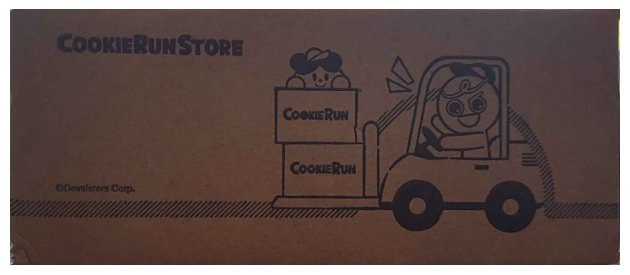

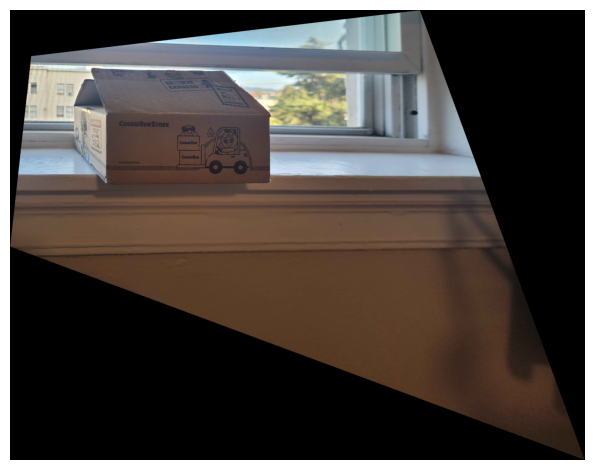

In [17]:
cookie_run = load_image("../img/CR.jpg")
cr_json = load_json("../json/CR_poc.json")
cr_H = computeH(np.array(cr_json['im1Points']), np.array(cr_json['im2Points']))
rect = rectify_rect(cookie_run,cr_H, cr_json,interp=1)
save_image("../out/CR_crop.jpg",rect)
show_image(rect)
whole = warpImageBilinear(cookie_run,cr_H)
save_image("../out/CR.jpg",whole)

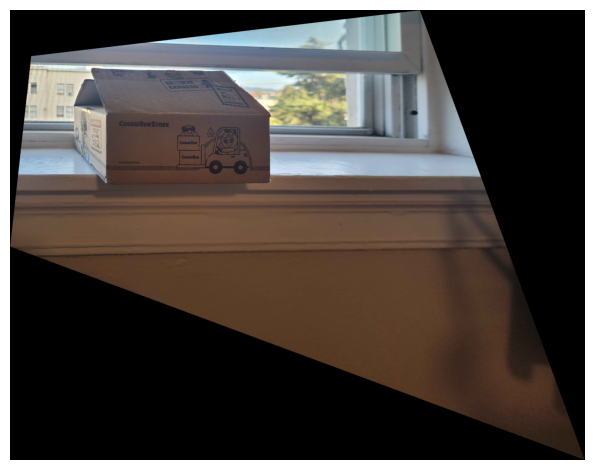

In [53]:
cookie_run = load_image("../img/tts.jpg")
cr_json = load_json("../json/tts_poc.json")
cr_H = computeH(np.array(cr_json['im1Points']), np.array(cr_json['im2Points']))
whole = warpImageNearestNeighbor(cookie_run,cr_H)
save_image("../out/TTSNN.jpg",whole)
cookie_run = load_image("../img/CR.jpg")
cr_json = load_json("../json/CR_poc.json")
cr_H = computeH(np.array(cr_json['im1Points']), np.array(cr_json['im2Points']))
whole = warpImageBilinear(cookie_run,cr_H)
save_image("../out/CRNN.jpg",whole)

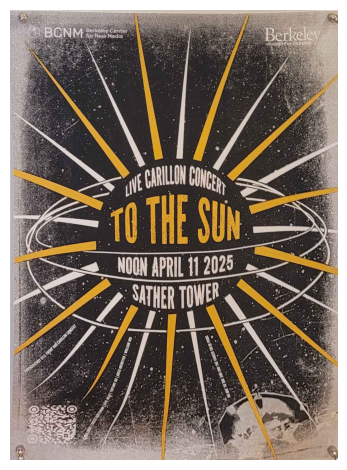

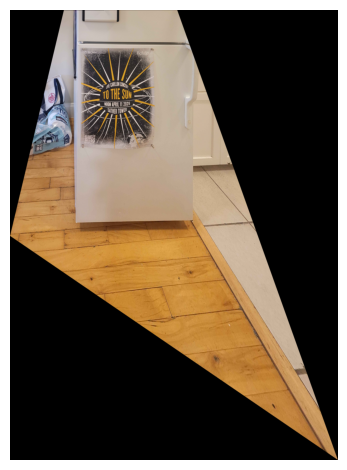

In [18]:
cookie_run = load_image("../img/tts.jpg")
cr_json = load_json("../json/tts_poc.json")
cr_H = computeH(np.array(cr_json['im1Points']), np.array(cr_json['im2Points']))
rect = rectify_rect(cookie_run,cr_H, cr_json,interp=1)
save_image("../out/TTS_crop.jpg",rect)
show_image(rect)
whole = warpImageBilinear(cookie_run,cr_H)
save_image("../out/TTS.jpg",whole)

In [ ]:
Lwindow = load_image('../img/Lwindow.jpg')
Rwindow = load_image('../img/Rwindow.jpg')
windowjson = load_json('../json/window.json')
window = mosaic(Rwindow,[Lwindow],[windowjson])
show_image(window)

In [52]:
computeH(np.array(windowjson['im1Points']),np.array(windowjson['im2Points']))

array([[ 1.42470405e+00, -4.70393852e-02, -1.56278839e+03],
       [ 3.50521273e-01,  1.28486393e+00, -6.84554970e+02],
       [ 1.50214230e-04,  6.37390464e-07,  1.00000000e+00]])

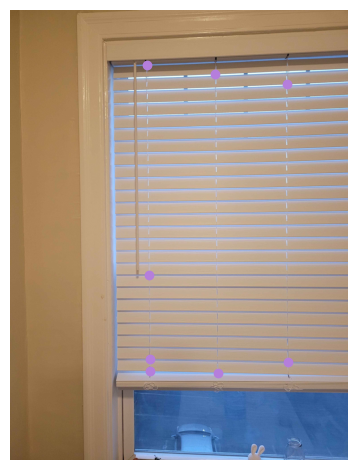

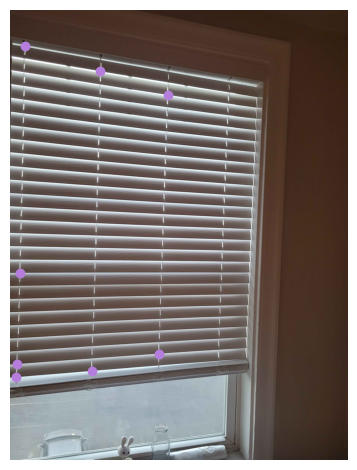

In [47]:
show_correspondance(Lwindow,windowjson,1,"../out/Lwindowc.jpg")
show_correspondance(Rwindow,windowjson,2,"../out/Rwindowc.jpg")